# Field inference of a single (realistic) source with the Fast Multipole Method

This notebook calcuates the potential of a single source via the Fast Multipole Method in 2D (https://github.com/flatironinstitute/fmm2d) and serves as a benchmark for our novel method.

Check for 2D magnetic field of a magnetized prism.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings
import equinox as eqx
import jax

from hypermagnetics import plots
from hypermagnetics.sources import read_db
from hypermagnetics.fmm_sources import potential2D, field2d_grid
from hypermagnetics.mt_eval import field_mt
from hypermagnetics.models.hyper_mlp import HyperLayer

warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

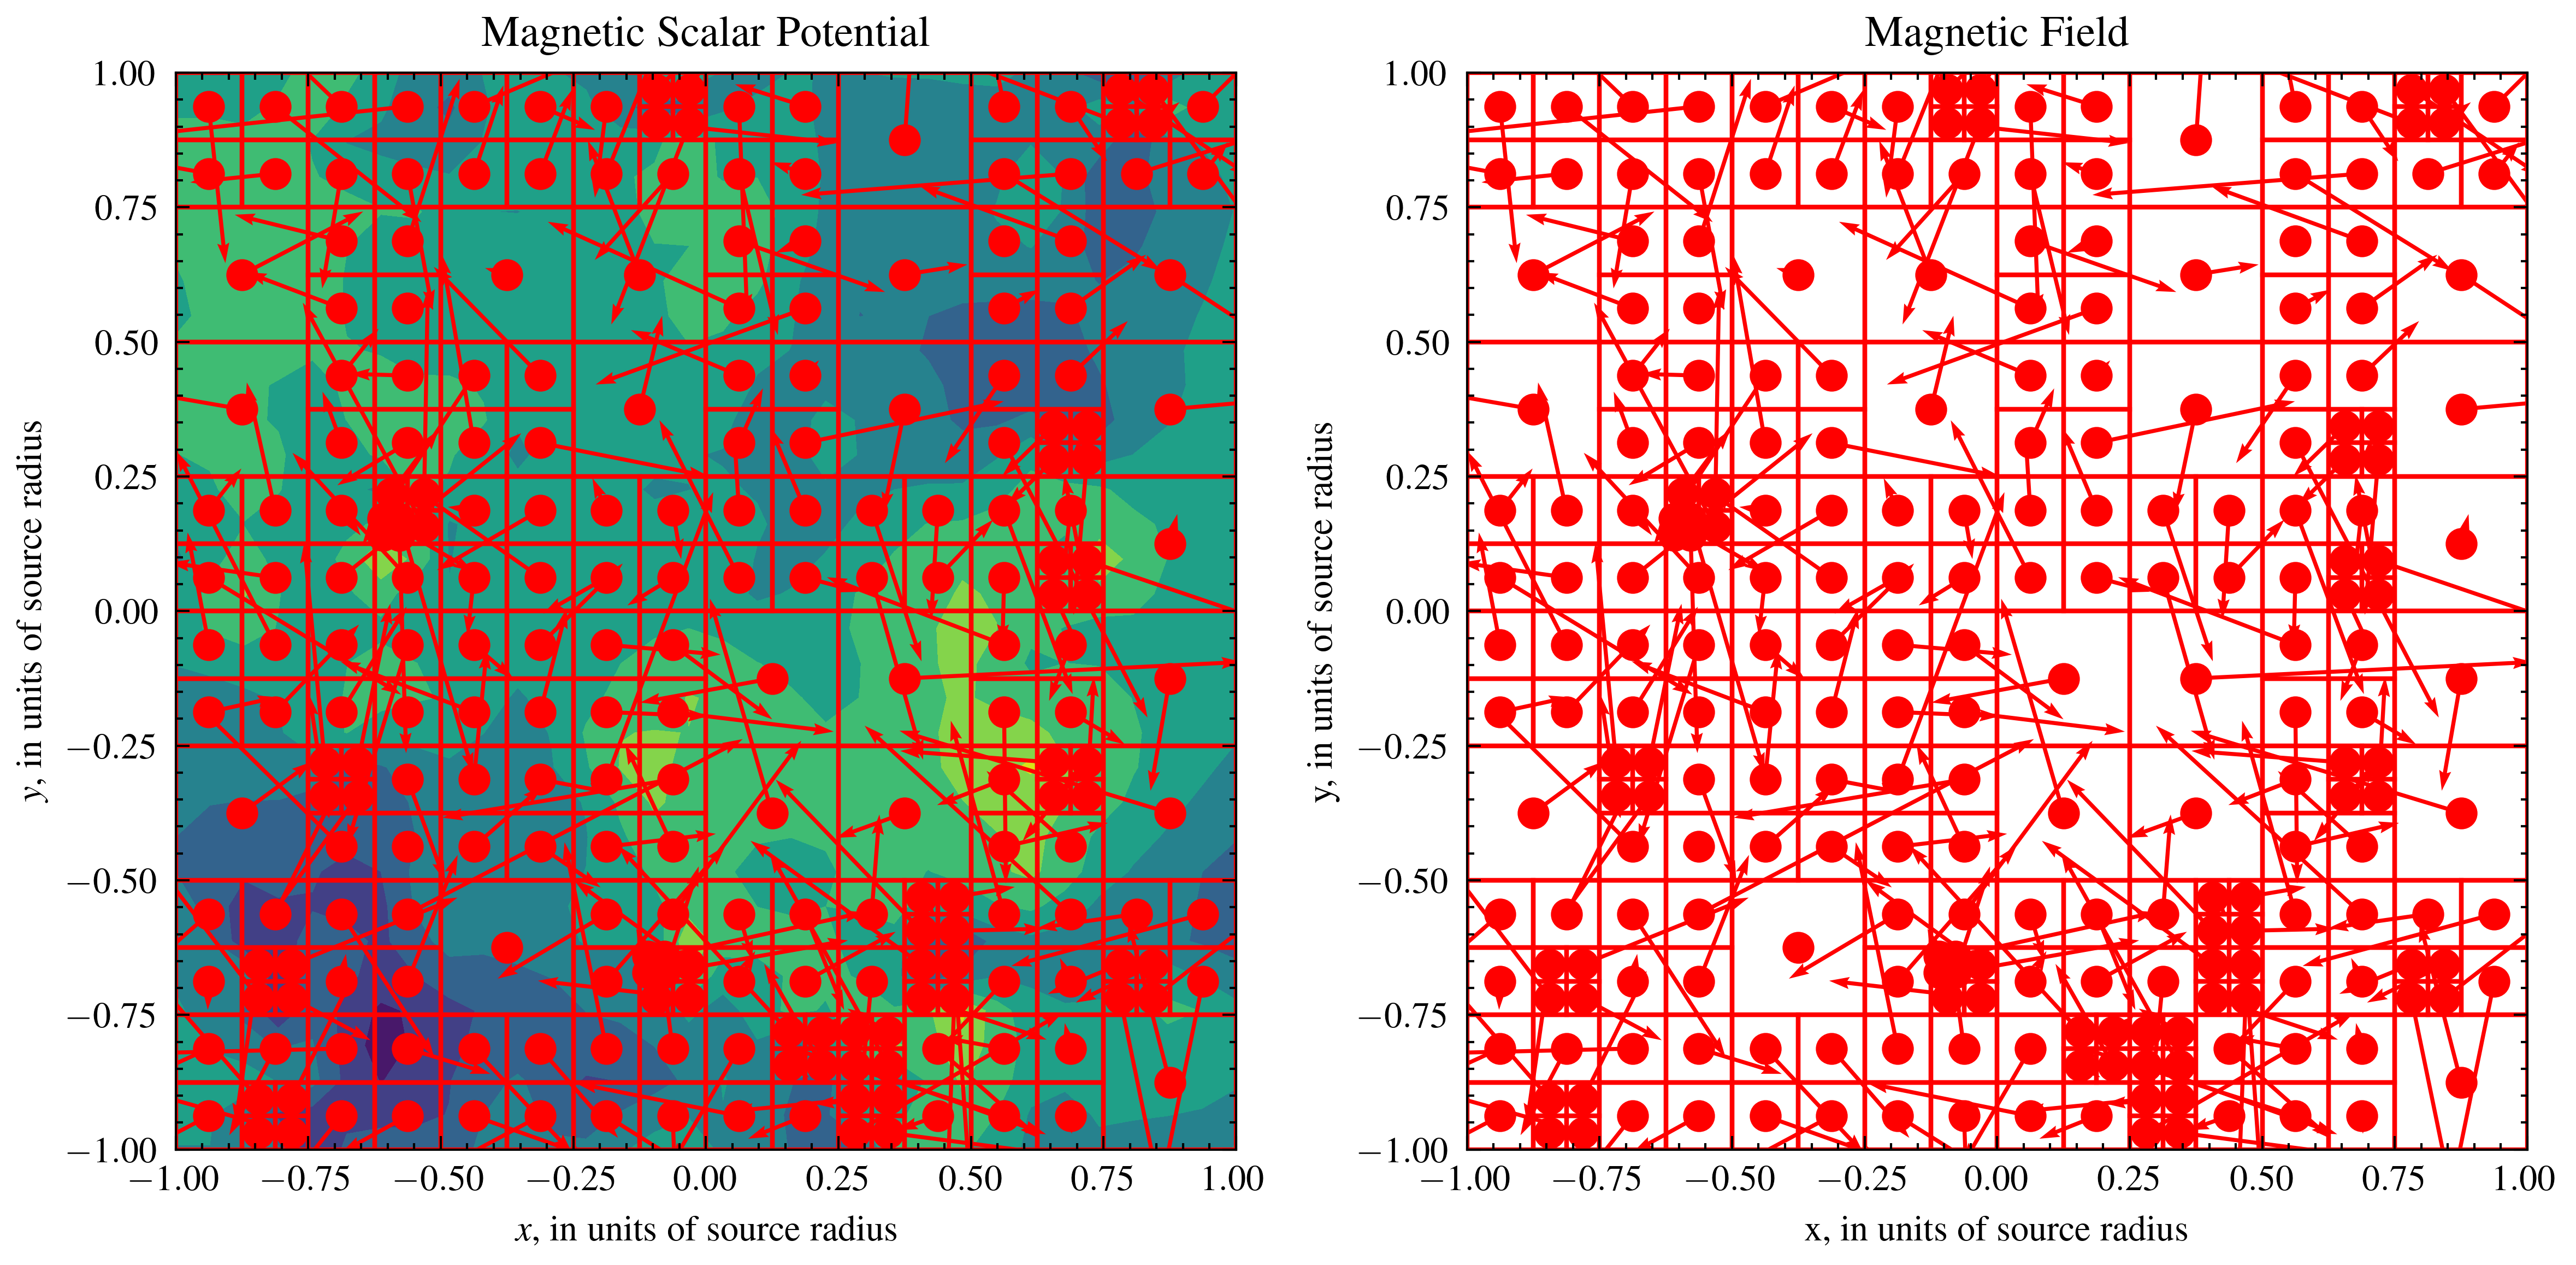

In [ ]:
source_cfg = {
    "shape": "prism",
    "n_samples": 1,
    "n_sources": 12,
    "lim": 1,
    "res": 32,
    "dim": 2,
    "min_size": 0.5,
    "max_size": 1,
    "target_source": True,
    "line": False,
    "quadtree": True,
    "eps": 0,
    "seed": 0,
}
# train = configure(**source_cfg)
db_name = "eval_qt_exact_42"
train = read_db(f"{db_name}_{5}_{250}.h5")
plots(train, loc=True, edge=True)

## Code from FMM2D
https://github.com/flatironinstitute/fmm2d/blob/main/src/laplace/rfmm2d.f#L144
- 2D dipole vector is represented in complex form `dx + i*dy`
- Can then be more easily treated as directional derivatives of monopole (source) potentials
- negative sign in `ztmp` is conventional; **TODO** Check how FMM is using this in Green's function

```
do i = 1,ns
    do j = 1,nd
        ztmp = -(dipvec(j,1,i)+eye*dipvec(j,2,i))
        dipstr1(j,i) = dipstr(j,i)*ztmp
    enddo
enddo
```


Potential: 0.09265522576443055


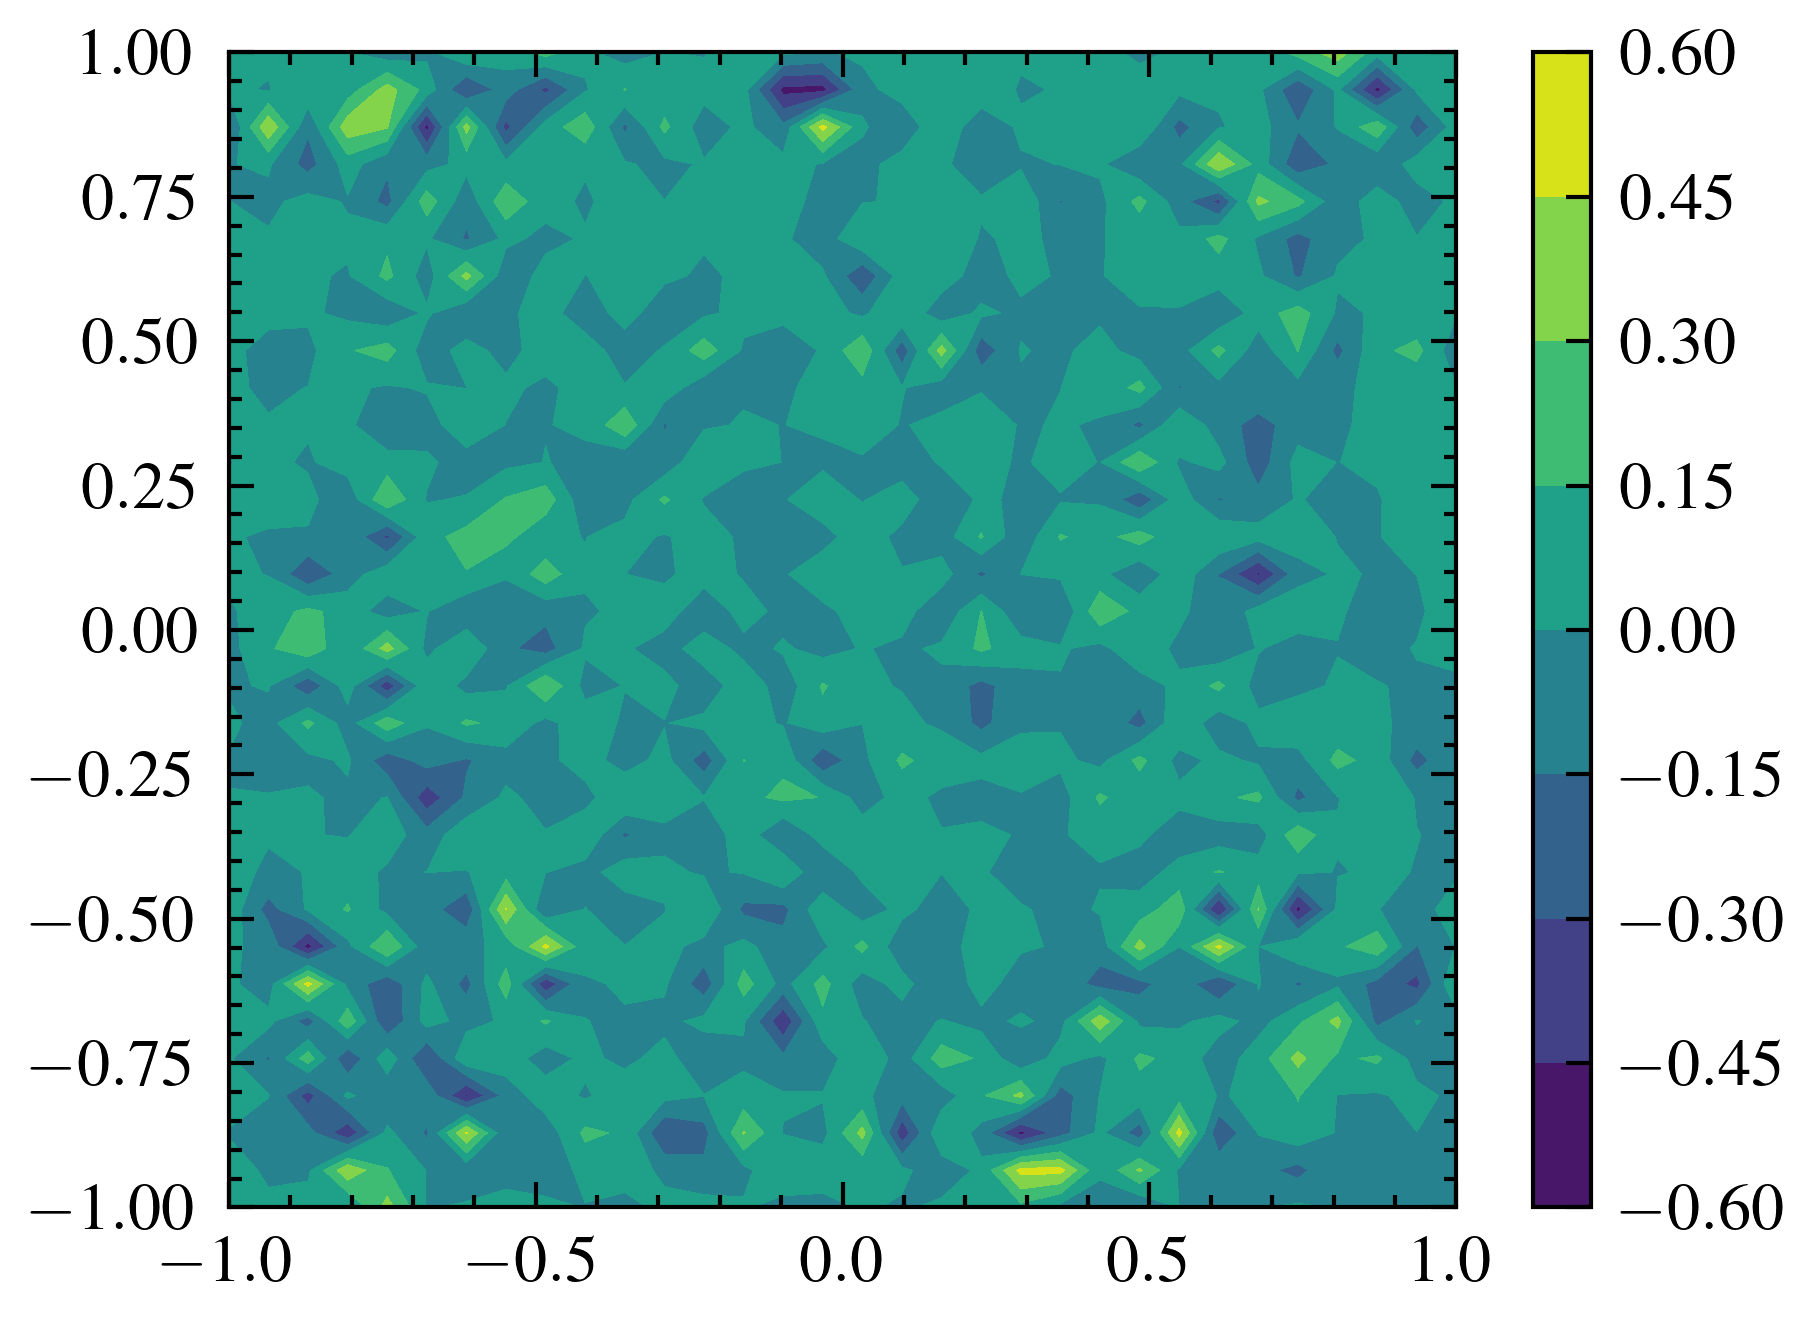

In [3]:
sim = train.copy()
sim['msp_grid'], _ = potential2D(sim['sources'], sim['shape'], sim['grid'])

### Potential
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["msp_grid"][0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["msp_grid"][0]), color='red', linestyle='--')
    plt.plot(sim['grid'][:, 0], np.abs(train["msp_grid"][0] - sim["msp_grid"][0]), color='green', linestyle=':')
    plt.yscale("log")
    plt.legend(["Prism3D", "Dipole", "Error"])
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_msp = sim["msp_grid"][0].reshape((source_cfg["res"], source_cfg["res"]))
    t_msp = train["msp_grid"][0].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, sim_msp)
    plt.contourf(x_grid, y_grid, np.clip(sim_msp - t_msp, -0.5, 0.5))
    plt.colorbar()

print("Potential:", np.nanmean(np.abs(sim_msp - t_msp)))

Field(y): 1.6685644763296508


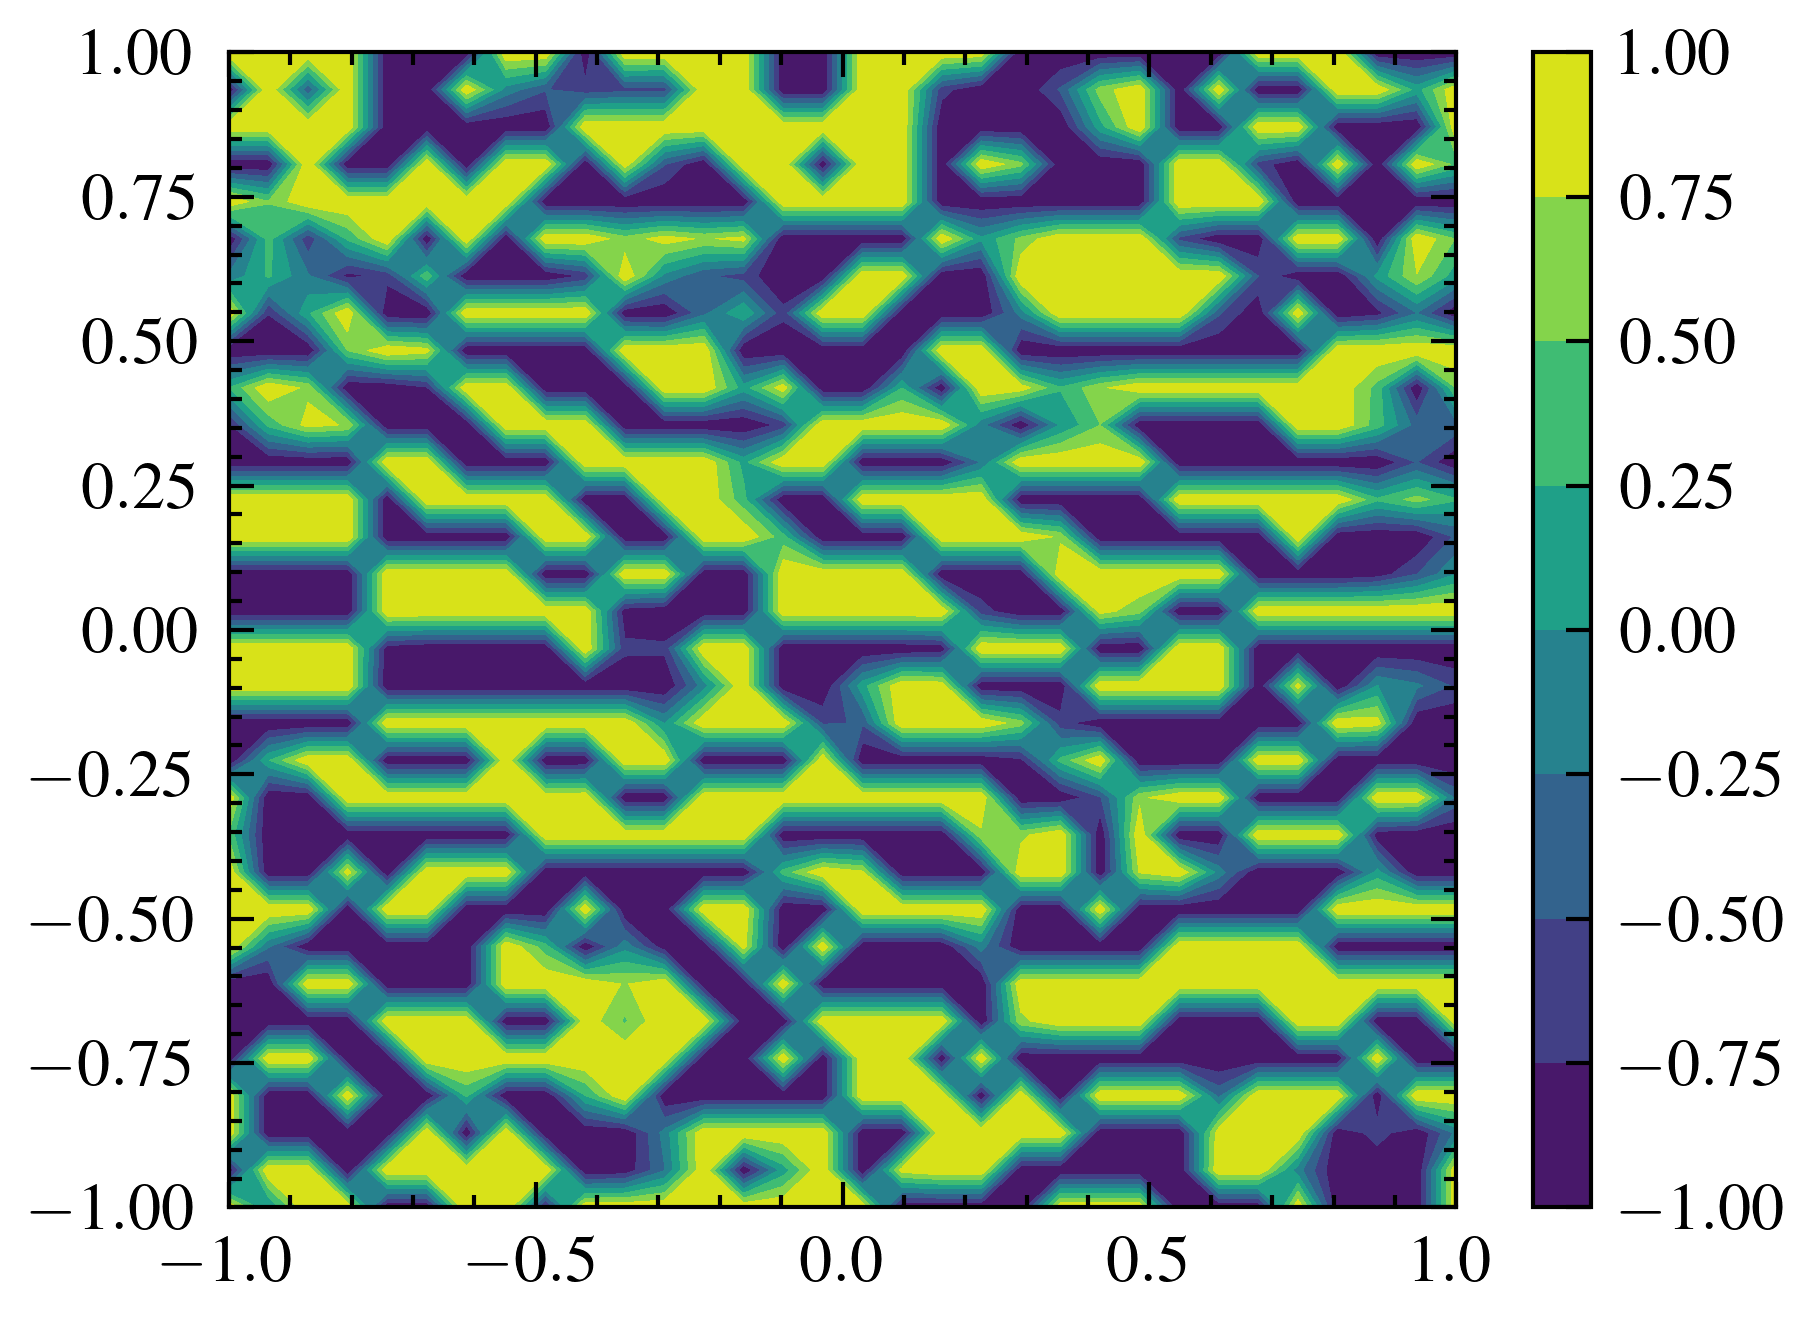

In [4]:
sim["field_grid"] = field2d_grid(source_cfg, sim["msp_grid"])
mt_sim, _ = field_mt(train['sources'], train['grid'], "prism")

### Field in x-direction
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["field_grid"][0, ..., 0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0, ..., 0]), color='red', linestyle='--')
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0] - sim["field_grid"][0]), color='green', linestyle=':')
    plt.yscale("log")
    plt.legend(["Prism3D", "Dipole", "Error"])
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_f = sim["field_grid"][0, ..., 1].reshape((source_cfg["res"], source_cfg["res"]))
    t_f = mt_sim[0, ..., 1].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f, -5, 5))
    # plt.contourf(x_grid, y_grid, np.clip(t_f, -1, 1))
    plt.contourf(x_grid, y_grid, np.clip(sim_f - t_f, -1, 1))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f / t_f, 0, 3))
    plt.colorbar()

    print("Field(y):", np.nanmean(np.abs(sim_f / t_f)))

## Directly from FMM2D

Field(y): 1.2862357960832485


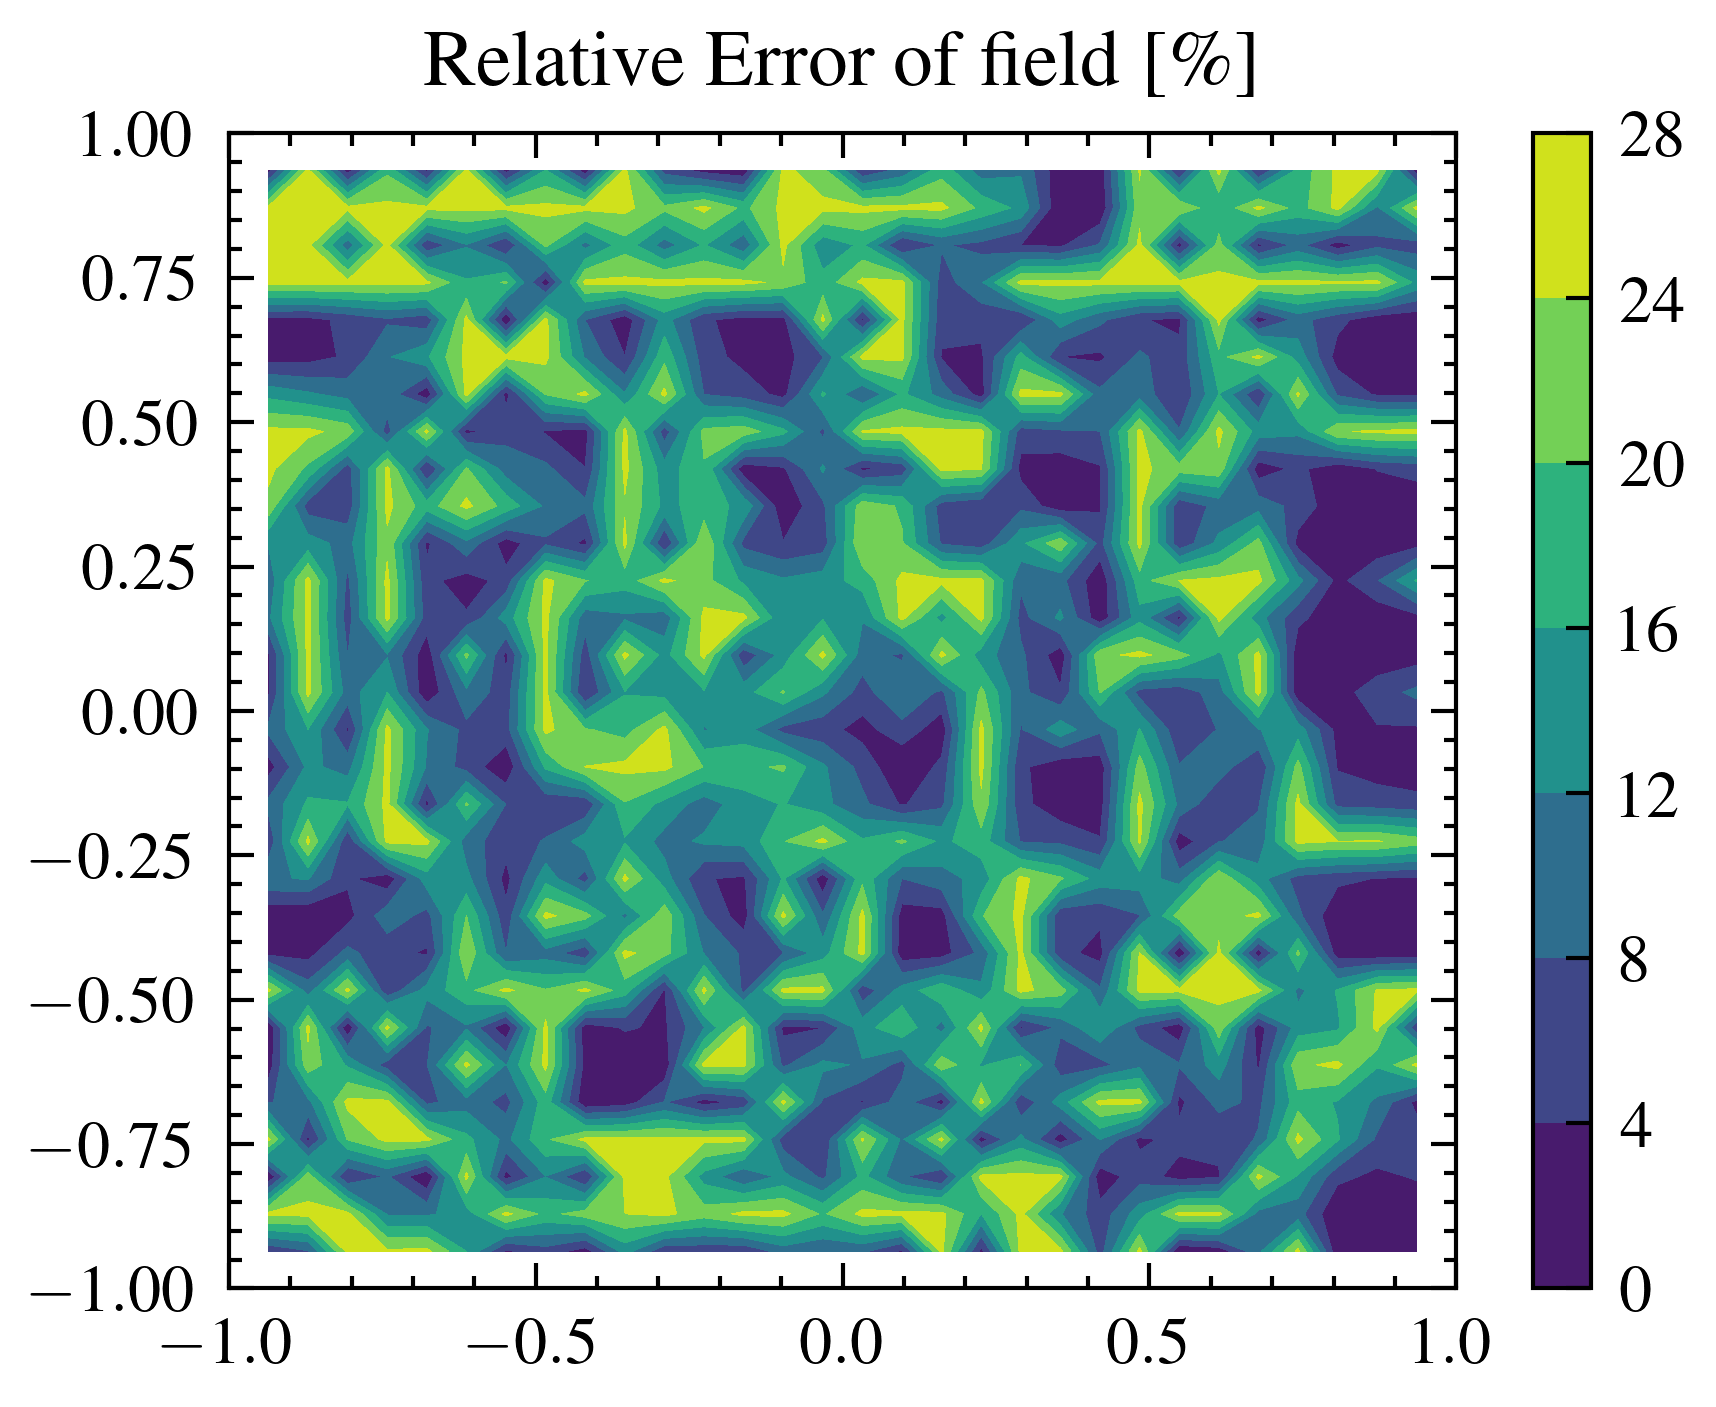

In [5]:
_, sim['field_grid_direct'] = potential2D(sim['sources'], sim['shape'], sim['grid'])

### Field in x-direction
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["field_grid_direct"][0, ..., 0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0, ..., 0]), color='red', linestyle='--')
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0] - sim["field_grid_direct"][0]), color='green', linestyle=':')
    plt.yscale("log")
    plt.legend(["Prism3D", "Dipole", "Error"])
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_f = sim["field_grid_direct"][0, ...]
    t_f = mt_sim[0, ..., :2]
    diff = np.linalg.norm(np.abs(sim_f - t_f), axis=-1).reshape((source_cfg["res"], source_cfg["res"]))
    norm_f = np.linalg.norm(t_f, axis=-1).reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f[...,1], -5, 5))
    # plt.contourf(x_grid, y_grid, np.clip(t_f[...,1], -1, 1))
    plt.contourf(x_grid, y_grid, np.clip((diff / norm_f) * 100, 0, 25))
    plt.title("Relative Error of field [\%]")
    # plt.contourf(x_grid, y_grid, np.clip(sim_f[...,1] / t_f[...,1], 0, 3))
    plt.colorbar()

    print("Field(y):", np.nanmean(np.abs(sim_f[...,1] / t_f[...,1])))

## Equivalent for MagTense
2D magnetiziation in $xy$-plane and prism is elongated in $z$-direction.

Convert magnetic moment to magnetization: $M = m / (2 * a * 2 * b)$

In [6]:
mt_sim, _ = field_mt(train['sources'], train['grid'], "prism")

if source_cfg["line"]:
    plt.plot(train['grid'][:, 0], train["field_grid"][0, ..., 0])
    plt.plot(train['grid'][:, 0], mt_sim[0, ..., 0], color='red', linestyle='--')
    # plt.plot(train['grid'][:, 0], train["field_grid"][0, ..., 0], color='red', linestyle='--')
    plt.plot(train['grid'][:, 0], mt_sim[0, ..., 0] / train["field_grid"][0, ..., 0], color='green', linestyle=':')
    # plt.yscale("log")
    # plt.xlim(5,15)
    plt.ylim(-2, 2)
    plt.legend(["Analytical", "MagTense", "Error"])
    print(np.nanmean(np.abs(mt_sim[0, :, 0] / train["field_grid"][0, :, 0])))

else:
    x_grid_pr = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid_pr = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    mt_f_grid_x = np.array(mt_sim[0, ..., 0].reshape((source_cfg["res"], source_cfg["res"])))
    t_f = train["field_grid"][0, ..., 0].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid_pr, y_grid_pr, np.clip(np.abs(mt_f_grid_x - t_f), 0, 1))
    # plt.colorbar()
    print(np.nanmean(np.abs(mt_f_grid_x / t_f)))

nan


In [7]:
for eps in [0, 1e-3, 1e-5, 1e-7, 1e-9]:
    # print("Source 1 on all other locations")
    # source = train['sources'][0:1, 0:1]
    # loc = train['r'][0][1:]
    # mt_sim, _ = field_mt(source, loc + eps, train['shape'])
    # # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    # _, fmm_field = potential2D(source, train['shape'], loc + eps)
    # # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    # rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    # print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")

    # print("Other sources on source 1")
    # source = train['sources'][0:1, 1:]
    # loc = train['r'][0][0:1]
    # mt_sim, _ = field_mt(source, loc + eps, train['shape'])
    # # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    # _, fmm_field = potential2D(source, train['shape'], loc + eps)
    # # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    # rel_err = np.abs((mt_sim[..., :2] - fmm_field) / mt_sim[..., :2]) * 100
    # print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")

    # print("Source 1 on all locations")
    source = train['sources'][0:1, 0:1]
    loc = train['r'][0]
    mt_sim_s, _ = field_mt(source, loc + eps, train['shape'])
    # print(np.mean(np.abs(mt_sim[0, ..., :2])))
    _, fmm_field = potential2D(source, train['shape'], loc + eps)
    # print(np.mean(np.abs(mt_sim[..., :2] - fmm_field)[0]))
    rel_err = np.abs((mt_sim_s[..., :2] - fmm_field) / mt_sim_s[..., :2]) * 100
    print(f"Eps: {eps:.1e}, Mean Error: {np.mean(rel_err):.2f} [%], Median Error: {np.median(rel_err):.2f} [%]")
    print(fmm_field[0, 0, :2])
    print(mt_sim_s[0, 0, :2])
    print("\n")

Eps: 0.0e+00, Mean Error: 2.55 [%], Median Error: 0.50 [%]
[-1.70100352 -6.94012276]
[-1.70100343 -6.94012305]


Eps: 1.0e-03, Mean Error: 2.44 [%], Median Error: 0.51 [%]
[-1.7100191  -6.95236299]
[-1.70072064 -6.94005373]


Eps: 1.0e-05, Mean Error: 22.82 [%], Median Error: 0.51 [%]
[-154.24424094  -87.8665553 ]
[-1.7010034  -6.94012304]


Eps: 1.0e-07, Mean Error: 277867.54 [%], Median Error: 0.51 [%]
[2113587.62614492 1018598.56109795]
[-1.70100343 -6.94012305]


Eps: 1.0e-09, Mean Error: 2.55 [%], Median Error: 0.50 [%]
[-1.70100352 -6.94012276]
[-1.70100343 -6.94012305]




# FC-INR field plots

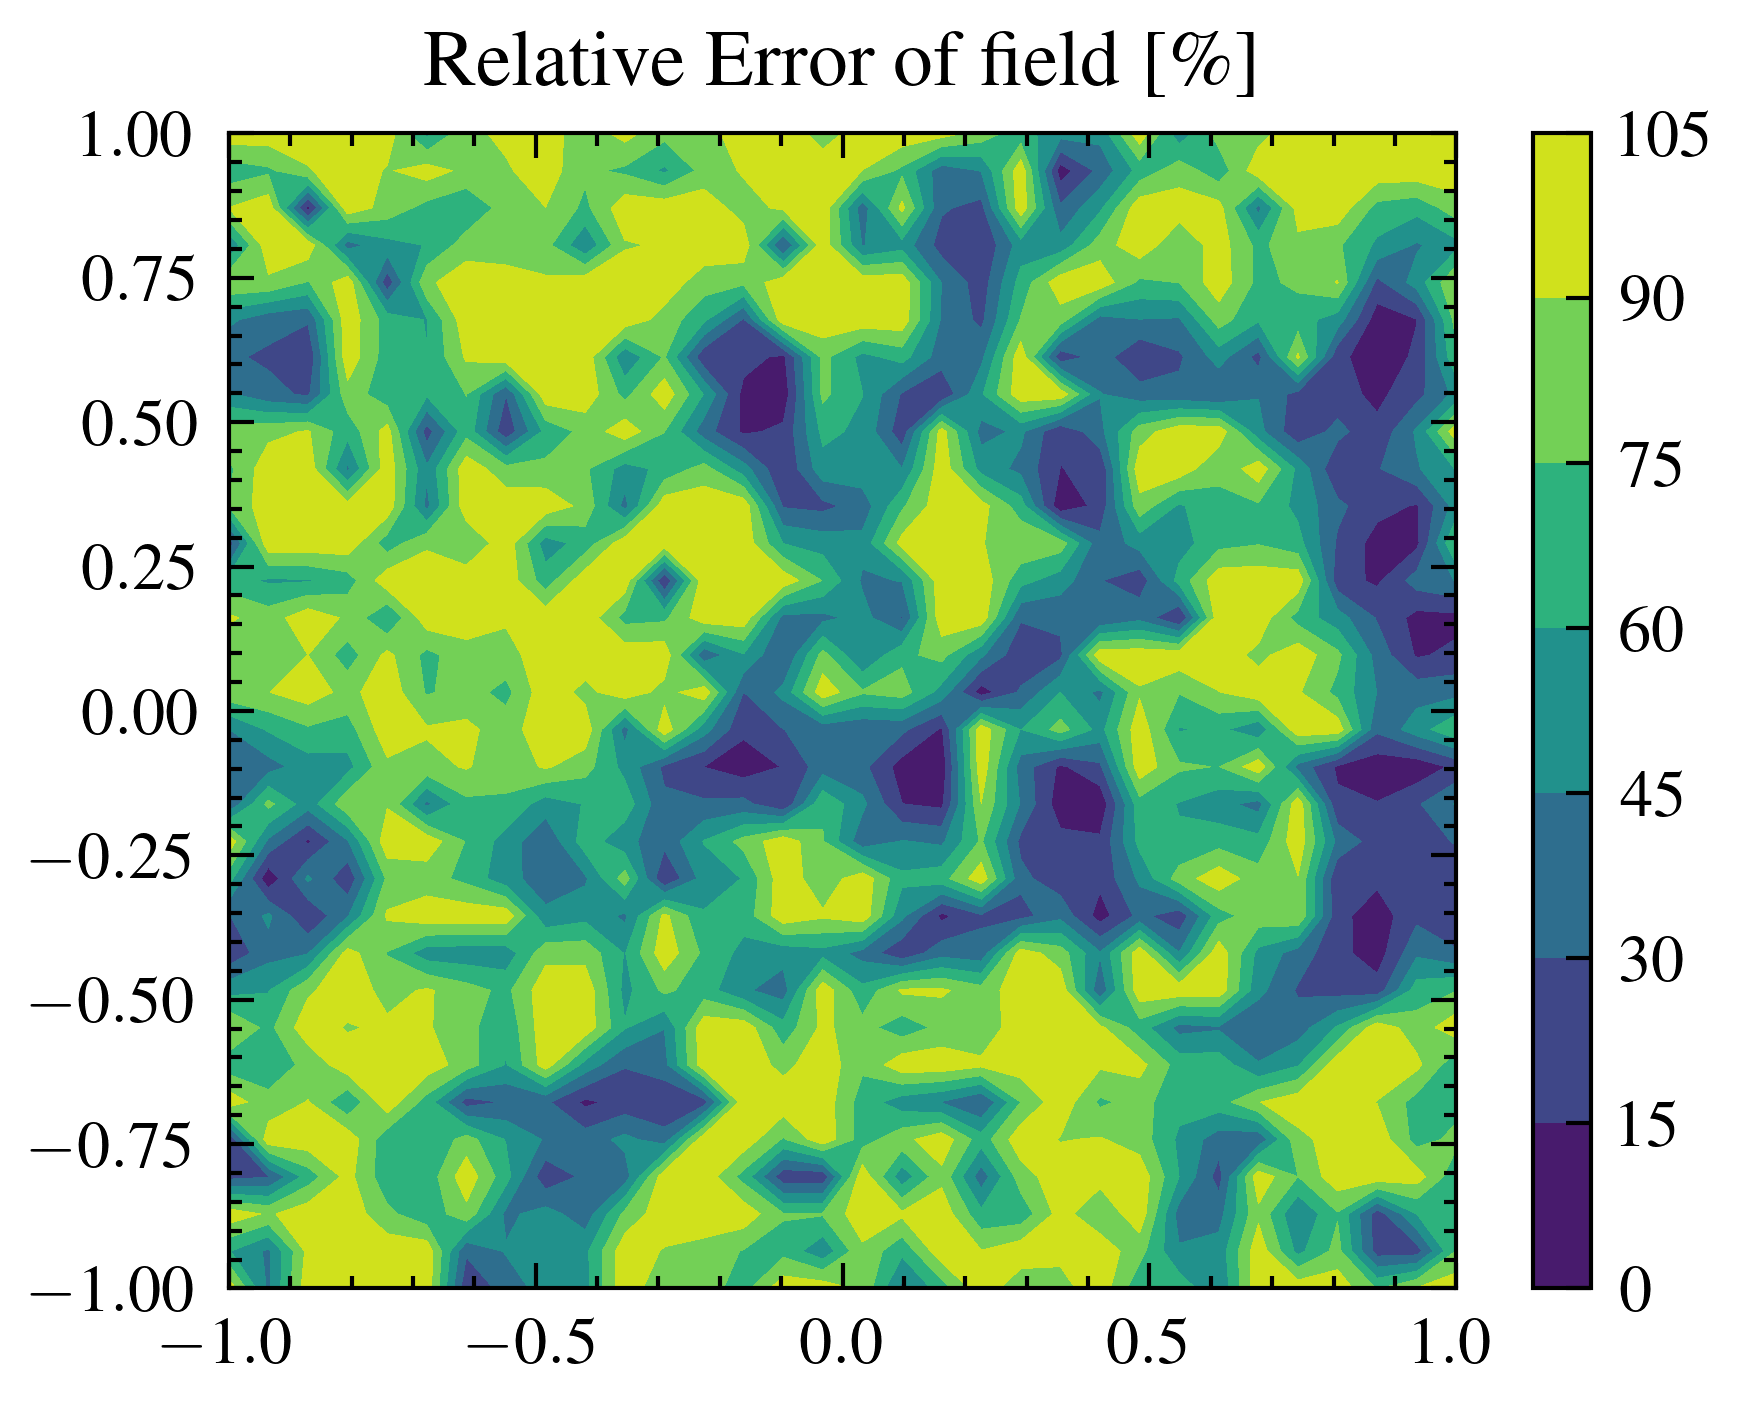

In [9]:
model_cfg = HyperLayer(
    width=400,
    depth=3,
    hwidth=2,
    hdepth=3,
    seed=42,
)
model_path = "/home/spol/Documents/repos/hypermagnetics/models/fcilr_400_200k_quadtree.eqx"
model = eqx.tree_deserialise_leaves(model_path, model_cfg)

sim['field_grid_model'] = jax.vmap(model.field, in_axes=(0, None))(
    train['sources'], train['grid']
)[0]
if not source_cfg["line"]:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_f = sim["field_grid_model"]
    t_f = mt_sim[0, ..., :2]
    diff = np.linalg.norm(np.abs(sim_f - t_f), axis=-1).reshape((source_cfg["res"], source_cfg["res"]))
    norm_f = np.linalg.norm(t_f, axis=-1).reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f[...,1].reshape((source_cfg["res"], source_cfg["res"])), -5, 5))
    # plt.contourf(x_grid, y_grid, np.clip(t_f[...,1].reshape((source_cfg["res"], source_cfg["res"])), -5, 5))
    plt.contourf(x_grid, y_grid, np.clip((diff / norm_f) * 100, 0, 100))
    plt.title("Relative Error of field [\%]")
    plt.colorbar()